<a href="https://colab.research.google.com/github/Kevangi/sketch-to-face-synthesis/blob/main/preprocessingSpilt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q opencv-python-headless tqdm

In [ ]:
import os
import cv2
import glob
import json
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
PROJECT_ROOT = '/content/drive/MyDrive/Sketch2Face'

RAW_SKETCH_DIR = os.path.join(PROJECT_ROOT, 'dataset', 'sketches')
RAW_PHOTO_DIR  = os.path.join(PROJECT_ROOT, 'dataset', 'photos')

PROCESSED_DIR  = os.path.join(PROJECT_ROOT, 'dataset', 'processed')
PROC_SKETCH    = os.path.join(PROCESSED_DIR, 'sketches')
PROC_PHOTO     = os.path.join(PROCESSED_DIR, 'photos')

SPLIT_DIR      = os.path.join(PROJECT_ROOT, 'dataset', 'split')
TRAIN_SKETCH   = os.path.join(SPLIT_DIR, 'train', 'sketches')
TRAIN_PHOTO    = os.path.join(SPLIT_DIR, 'train', 'photos')
TEST_SKETCH    = os.path.join(SPLIT_DIR, 'test',  'sketches')
TEST_PHOTO     = os.path.join(SPLIT_DIR, 'test',  'photos')

for d in [PROC_SKETCH, PROC_PHOTO,
          TRAIN_SKETCH, TRAIN_PHOTO,
          TEST_SKETCH,  TEST_PHOTO]:
    os.makedirs(d, exist_ok=True)

# ── Config ───────────────────────────────────────────────────────────────────
CONFIG = {
    'image_size'  : 256,
    'train_ratio' : 0.80,
    'test_ratio'  : 0.20,
    'random_seed' : 42,
}

VALID_EXTS = {'.png', '.jpg', '.jpeg', '.bmp'}

print('Project root  :', PROJECT_ROOT)
print('Raw sketches  :', RAW_SKETCH_DIR)
print('Raw photos    :', RAW_PHOTO_DIR)
print('Processed dir :', PROCESSED_DIR)
print('Split dir     :', SPLIT_DIR)
print('Config        :', CONFIG)

Project root  : /content/drive/MyDrive/Sketch2Face
Raw sketches  : /content/drive/MyDrive/Sketch2Face/dataset/sketches
Raw photos    : /content/drive/MyDrive/Sketch2Face/dataset/photos
Processed dir : /content/drive/MyDrive/Sketch2Face/dataset/processed
Split dir     : /content/drive/MyDrive/Sketch2Face/dataset/split
Config        : {'image_size': 256, 'train_ratio': 0.8, 'test_ratio': 0.2, 'random_seed': 42}


In [ ]:
def normalize_sketch_name(name):
    """
    Normalize sketch filename stem so it matches the corresponding photo stem.
      sketch M2-005-sz1 -> m-005
      sketch F2-005-sz1 -> f-005
    """
    name = name.lower()
    name = name.replace("-sz1", "")       # remove sketch size tag
    if name.startswith("m2"):
        name = name.replace("m2", "m", 1)
    if name.startswith("f2"):
        name = name.replace("f2", "f", 1)
    return name


def preprocess_image(img_path, img_size, is_sketch=False):
    """
    Load -> Resize -> (Grayscale if sketch) -> Normalize to [-1, 1].

    Args:
        img_path  : path to the image file
        img_size  : target square size (e.g. 256)
        is_sketch : if True, converts to grayscale then back to 3-channel

    Returns:
        float32 numpy array of shape (H, W, 3), values in [-1, 1]
    """
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {img_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LANCZOS4)

    if is_sketch:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        img  = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    img = img.astype(np.float32) / 127.5 - 1.0
    return img


def save_preprocessed(arr, out_path):
    """
    Save a float32 [-1, 1] array back to uint8 PNG for disk storage.
    """
    uint8_img = ((arr + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    bgr       = cv2.cvtColor(uint8_img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(out_path, bgr)


print("Helper functions defined.")

Helper functions defined.


In [ ]:
def stem(path):
    return os.path.splitext(os.path.basename(path))[0]

sketch_files = [p for p in glob.glob(os.path.join(RAW_SKETCH_DIR, "**", "*"), recursive=True)
                if os.path.splitext(p)[1].lower() in VALID_EXTS]
photo_files  = [p for p in glob.glob(os.path.join(RAW_PHOTO_DIR,  "**", "*"), recursive=True)
                if os.path.splitext(p)[1].lower() in VALID_EXTS]

# Build maps: normalized_stem -> full_path
# Both sketch and photo names are normalized before matching
sketch_map = {normalize_sketch_name(stem(p)): p for p in sketch_files}
photo_map  = {stem(p):  p for p in photo_files}

common_ids  = sorted(set(sketch_map.keys()) & set(photo_map.keys()))
sketch_only = set(sketch_map.keys()) - set(photo_map.keys())
photo_only  = set(photo_map.keys())  - set(sketch_map.keys())

paired_raw = [
    {"id": sid, "sketch": sketch_map[sid], "photo": photo_map[sid]}
    for sid in common_ids
]

print(f"Sketches found         : {len(sketch_files)}")
print(f"Photos found           : {len(photo_files)}")
print(f"Valid matched pairs    : {len(paired_raw)}")
print(f"Sketches without photo : {len(sketch_only)}")
print(f"Photos without sketch  : {len(photo_only)}")

if sketch_only:
    print(f"  Unmatched sketches : {sorted(sketch_only)}")
if photo_only:
    print(f"  Unmatched photos   : {sorted(photo_only)}")

Sketches found         : 188
Photos found           : 188
Valid matched pairs    : 188
Sketches without photo : 0
Photos without sketch  : 0


In [ ]:
IMG_SIZE = CONFIG['image_size']

paired_processed = []
failed           = []

for pair in tqdm(paired_raw, desc='Preprocessing'):
    sid        = pair['id']
    out_sketch = os.path.join(PROC_SKETCH, f'{sid}.png')
    out_photo  = os.path.join(PROC_PHOTO,  f'{sid}.png')

    try:
        sketch_arr = preprocess_image(pair['sketch'], IMG_SIZE, is_sketch=True)
        photo_arr  = preprocess_image(pair['photo'],  IMG_SIZE, is_sketch=False)

        save_preprocessed(sketch_arr, out_sketch)
        save_preprocessed(photo_arr,  out_photo)

        paired_processed.append({'id': sid, 'sketch': out_sketch, 'photo': out_photo})

    except Exception as e:
        failed.append({'id': sid, 'error': str(e)})
        print(f'  FAILED: {sid} — {e}')

print(f'\nPreprocessed successfully : {len(paired_processed)}')
print(f'Failed                    : {len(failed)}')

Preprocessing:   0%|          | 0/188 [00:00<?, ?it/s]


Preprocessed successfully : 188
Failed                    : 0


In [ ]:
print('Verifying preprocessed images...')
errors = []

for pair in tqdm(paired_processed, desc='Verifying'):
    for key in ('sketch', 'photo'):
        img = cv2.imread(pair[key])
        if img is None:
            errors.append(f"Cannot read: {pair[key]}")
            continue
        h, w, c = img.shape
        if h != IMG_SIZE or w != IMG_SIZE:
            errors.append(f"Wrong size {w}x{h}: {pair[key]}")
        if c != 3:
            errors.append(f"Expected 3 channels, got {c}: {pair[key]}")

if errors:
    print(f'{len(errors)} error(s) found:')
    for e in errors:
        print(f'  {e}')
else:
    # Check pixel range on first pair
    sample  = paired_processed[0]
    s_check = cv2.imread(sample['sketch']).astype(np.float32)
    p_check = cv2.imread(sample['photo']).astype(np.float32)
    print(f'Sample sketch — shape: {s_check.shape}, dtype: {s_check.dtype}, pixel range: [{s_check.min():.0f}, {s_check.max():.0f}]')
    print(f'Sample photo  — shape: {p_check.shape}, dtype: {p_check.dtype}, pixel range: [{p_check.min():.0f}, {p_check.max():.0f}]')
    print(f'\nAll {len(paired_processed)} preprocessed images verified OK.')

Verifying preprocessed images...


Verifying:   0%|          | 0/188 [00:00<?, ?it/s]

Sample sketch — shape: (256, 256, 3), dtype: float32, pixel range: [7, 255]
Sample photo  — shape: (256, 256, 3), dtype: float32, pixel range: [0, 255]

All 188 preprocessed images verified OK.


In [ ]:
random.seed(CONFIG['random_seed'])
shuffled = paired_processed.copy()
random.shuffle(shuffled)

n_total = len(shuffled)
n_test  = max(1, round(n_total * CONFIG['test_ratio']))
n_train = n_total - n_test

train_pairs = shuffled[:n_train]
test_pairs  = shuffled[n_train:]

print(f'Total : {n_total}  |  Train : {n_train}  |  Test : {n_test}')
print()

def copy_split(pairs, sketch_dir, photo_dir, split_name):
    """Copy preprocessed images into split folder and return manifest records."""
    records = []
    for pair in tqdm(pairs, desc=f'Copying {split_name}'):
        dst_s = os.path.join(sketch_dir, f"{pair['id']}.png")
        dst_p = os.path.join(photo_dir,  f"{pair['id']}.png")
        shutil.copy2(pair['sketch'], dst_s)
        shutil.copy2(pair['photo'],  dst_p)
        records.append({'id': pair['id'], 'sketch': dst_s, 'photo': dst_p})

    manifest_path = os.path.join(SPLIT_DIR, f'{split_name}.json')
    with open(manifest_path, 'w') as f:
        json.dump(records, f, indent=2)
    print(f'  Manifest saved -> {manifest_path}')
    return records

train_records = copy_split(train_pairs, TRAIN_SKETCH, TRAIN_PHOTO, 'train')
test_records  = copy_split(test_pairs,  TEST_SKETCH,  TEST_PHOTO,  'test')

Total : 188  |  Train : 150  |  Test : 38



Copying train:   0%|          | 0/150 [00:00<?, ?it/s]

  Manifest saved -> /content/drive/MyDrive/Sketch2Face/dataset/split/train.json


Copying test:   0%|          | 0/38 [00:00<?, ?it/s]

  Manifest saved -> /content/drive/MyDrive/Sketch2Face/dataset/split/test.json


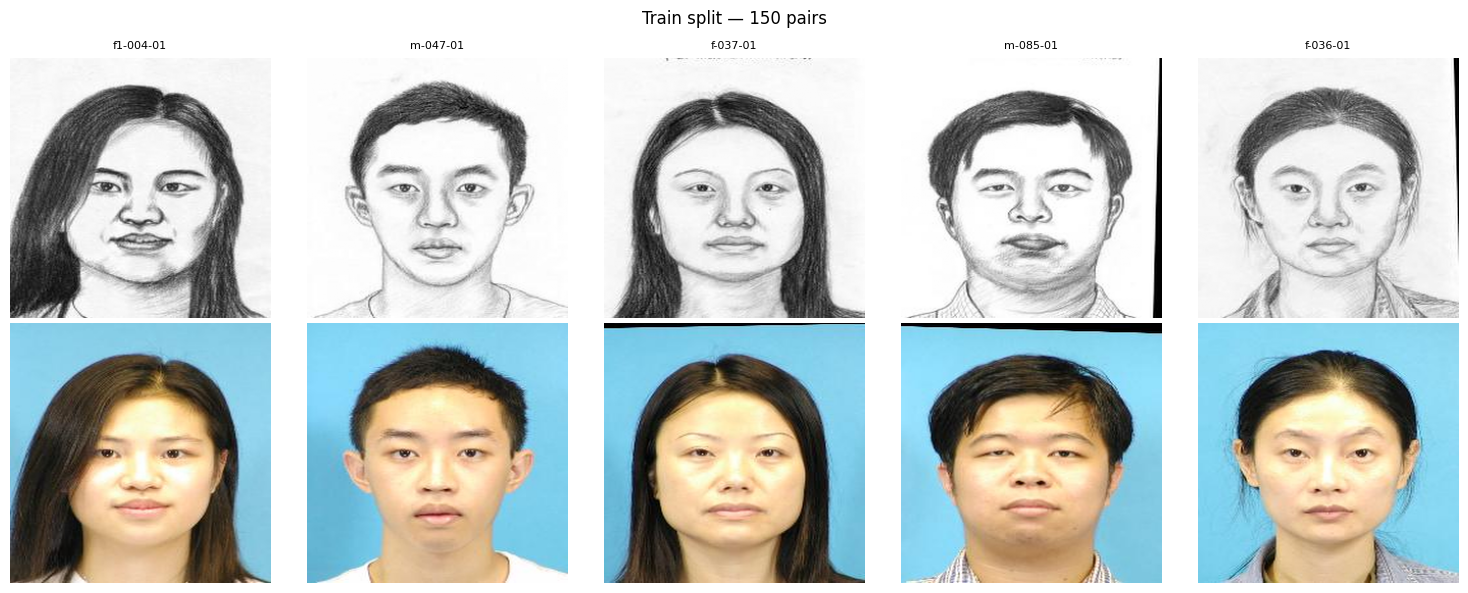

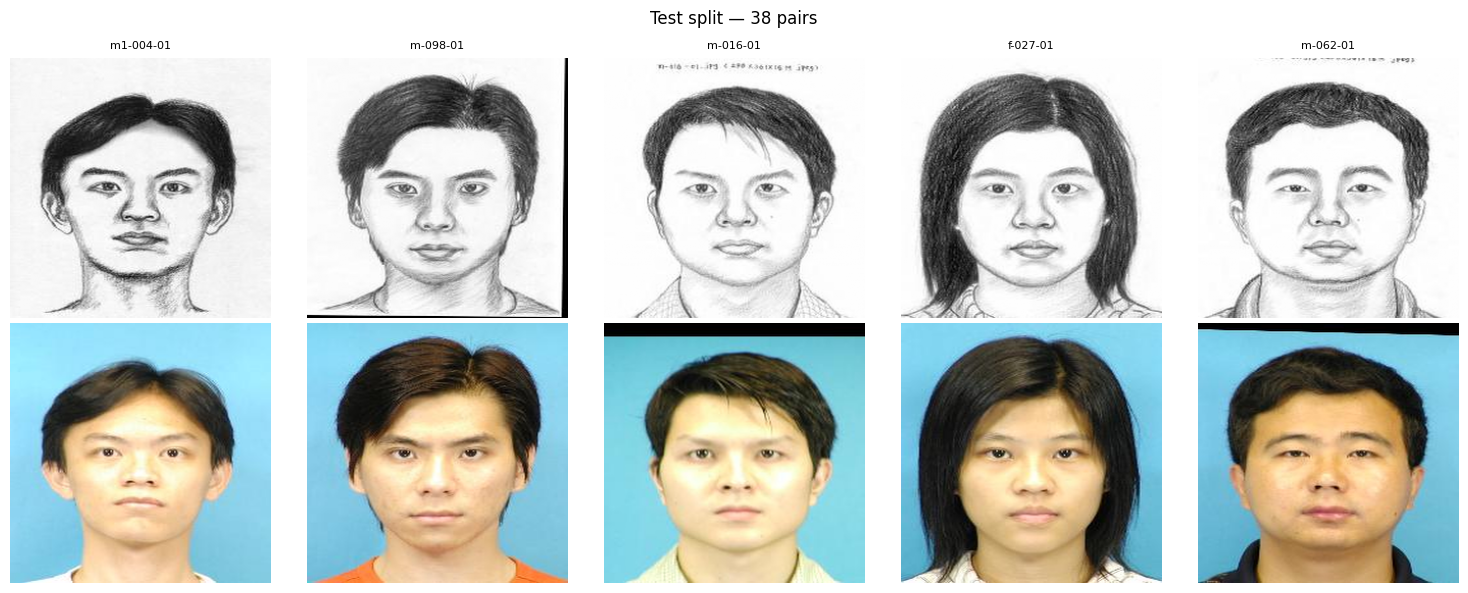

In [ ]:
def show_split(records, split_name, n=5):
    samples = random.sample(records, min(n, len(records)))
    fig, axes = plt.subplots(2, len(samples), figsize=(len(samples) * 3, 6))
    fig.suptitle(f'{split_name} split — {len(records)} pairs', fontsize=12)
    for i, rec in enumerate(samples):
        sketch_disp = cv2.cvtColor(cv2.imread(rec['sketch']), cv2.COLOR_BGR2GRAY)
        photo_disp  = cv2.cvtColor(cv2.imread(rec['photo']),  cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(sketch_disp, cmap='gray')
        axes[0, i].set_title(rec['id'], fontsize=8)
        axes[0, i].axis('off')
        axes[1, i].imshow(photo_disp)
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Sketch', fontsize=10)
    axes[1, 0].set_ylabel('Photo',  fontsize=10)
    plt.tight_layout()
    plt.show()

show_split(train_records, 'Train')
show_split(test_records,  'Test')

In [ ]:
print('=' * 55)
print('Preprocessing & Split Summary')
print('=' * 55)
print(f'Total pairs preprocessed : {len(paired_processed)}')
print(f'Train pairs              : {len(train_records)}')
print(f'Test pairs               : {len(test_records)}')
print()
print('Preprocessing steps (applied to every image):')
print(f'  1. Read with OpenCV (BGR -> RGB)')
print(f'  2. Resize to {IMG_SIZE}x{IMG_SIZE} (Lanczos interpolation)')
print(f'  3. Sketch: grayscale -> 3-channel RGB')
print(f'  4. Normalize: [0,255] -> [-1, 1]  (/ 127.5 - 1)')
print(f'  5. Save as uint8 PNG to data/processed/')
print()
print('Folder structure created:')
print(f'  Sketch2Face/')
print(f'  ├── dataset/sketches/         <- raw input (unchanged)')
print(f'  ├── dataset/photos/           <- raw input (unchanged)')
print(f'  └── data/')
print(f'      ├── processed/sketches/   <- all {len(paired_processed)} preprocessed sketches')
print(f'      ├── processed/photos/     <- all {len(paired_processed)} preprocessed photos')
print(f'      └── split/')
print(f'          ├── train.json        <- {len(train_records)} pairs manifest')
print(f'          ├── test.json         <- {len(test_records)} pairs manifest')
print(f'          ├── train/sketches/')
print(f'          ├── train/photos/')
print(f'          ├── test/sketches/')
print(f'          └── test/photos/')
print('=' * 55)

Preprocessing & Split Summary
Total pairs preprocessed : 188
Train pairs              : 150
Test pairs               : 38

Preprocessing steps (applied to every image):
  1. Read with OpenCV (BGR -> RGB)
  2. Resize to 256x256 (Lanczos interpolation)
  3. Sketch: grayscale -> 3-channel RGB
  4. Normalize: [0,255] -> [-1, 1]  (/ 127.5 - 1)
  5. Save as uint8 PNG to data/processed/

Folder structure created:
  Sketch2Face/
  ├── dataset/sketches/         <- raw input (unchanged)
  ├── dataset/photos/           <- raw input (unchanged)
  └── data/
      ├── processed/sketches/   <- all 188 preprocessed sketches
      ├── processed/photos/     <- all 188 preprocessed photos
      └── split/
          ├── train.json        <- 150 pairs manifest
          ├── test.json         <- 38 pairs manifest
          ├── train/sketches/
          ├── train/photos/
          ├── test/sketches/
          └── test/photos/
